# Análise do programa Bicicletar de 2014 a 2025
Recentemente, o programa Bicicletar atingiu a marca de 9 milhões de viagens realizadas, dessa forma, o objetivo deste projeto é analisar os dados
disponibilizados pela Autarquia Municipal de Trânsito e Cidadania (AMC) e a prefeitura de Fortaleza.

In [ ]:
# Importando bibliotecas necessárias
import pandas as pd # Manipulação de dados
import plotly.express as px # Criação de gráficos interativos
from scipy import stats # Testes estatísticos variados
import pymannkendall as mk # Teste de Mann-Kendall

In [ ]:
### Carregar os dados
dados2014 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2014.csv")
dados2015 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2015.csv")
dados2016 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2016.csv")
dados2017 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2017.csv")
dados2018 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2018.csv")
dados2019 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2019.csv")
dados2021 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2021.csv")
dados2022 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2022.csv", dtype={'Sexo': str})
dados2023 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2023.csv")
dados2024 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2024.csv")
dados2025 = pd.read_csv("Dados/dadosabertos_viagensbicicletar_2025.csv")

In [ ]:
# Juntar os dados de todos os anos
dados_total = pd.concat([dados2014,dados2015,dados2016,dados2017,dados2018,dados2019,dados2021,dados2022,dados2023,dados2024,dados2025], ignore_index=True)
display(dados_total.info()) # Exibir informações sobre o DataFrame combinado

<class 'pandas.DataFrame'>
RangeIndex: 7547072 entries, 0 to 7547071
Data columns (total 12 columns):
 #   Column            Dtype
---  ------            -----
 0   MeioRetirada      str  
 1   IdUsuario         int64
 2   Sexo              str  
 3   DataViagem        str  
 4   HoraRetirada      str  
 5   EstacaoRetirada   int64
 6   HoraDevolucao     str  
 7   EstacaoDevolucao  int64
 8   DuracaoViagem     int64
 9   TipoEstacao       str  
 10  TipoBicicleta     str  
 11  AnoViagem         int64
dtypes: int64(5), str(7)
memory usage: 1.0 GB


None

In [ ]:
# Corrigir o tipo de dado de algumas colunas

dados_total['AnoViagem'] = dados_total['AnoViagem'].astype(str) # Apesar de ser uma data, é transformado em string para facilitar a análise e visualização
dados_total['DataViagem'] = pd.to_datetime(dados_total['DataViagem'], format='%Y-%m-%d')
dados_total['HoraRetirada'] = pd.to_datetime(dados_total['HoraRetirada'], format='%H:%M:%S', errors='coerce').dt.time
dados_total['HoraDevolucao'] = pd.to_datetime(dados_total['HoraDevolucao'], format='%H:%M:%S', errors='coerce').dt.time
display(dados_total.info()) # Exibir informações sobre o DataFrame combinado após a correção dos tipos de dados

<class 'pandas.DataFrame'>
RangeIndex: 7547072 entries, 0 to 7547071
Data columns (total 12 columns):
 #   Column            Dtype         
---  ------            -----         
 0   MeioRetirada      str           
 1   IdUsuario         int64         
 2   Sexo              str           
 3   DataViagem        datetime64[us]
 4   HoraRetirada      object        
 5   EstacaoRetirada   int64         
 6   HoraDevolucao     object        
 7   EstacaoDevolucao  int64         
 8   DuracaoViagem     int64         
 9   TipoEstacao       str           
 10  TipoBicicleta     str           
 11  AnoViagem         str           
dtypes: datetime64[us](1), int64(4), object(2), str(5)
memory usage: 906.8+ MB


None

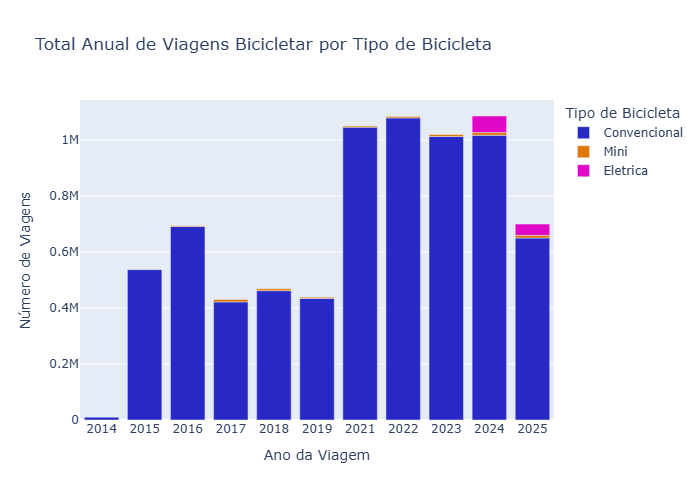

In [ ]:
# Visualizando o total de viagens por tipo de bicicleta

viagens_ano_tipo = dados_total.groupby(['AnoViagem', 'TipoBicicleta']).size().reset_index(name='Quantidade') # Agrupando antes para evitar alto consumo de memória

grafico1 =px.bar(
    viagens_ano_tipo,
    x='AnoViagem', 
    y='Quantidade',
    color='TipoBicicleta', 
    title='Total Anual de Viagens Bicicletar por Tipo de Bicicleta',
    labels={'AnoViagem': 'Ano da Viagem', 'Quantidade': 'Número de Viagens', 'TipoBicicleta': 'Tipo de Bicicleta'},
    color_discrete_sequence=['#2828c7', '#e07707', '#e007c7']
)

grafico1.show(renderer="png") # Exibir o gráfico de forma que seja possível visualizar no GitHub

#### Observações sobre a contagem de viagens:
- 2014: Apresenta um baixo volume de viagens, pois o programa foi iniciado apenas em dezembro daquele ano.
- 2025: Possui um registro substancialmente menor em relação a 2024 devido à data de corte dos dados (atualizados apenas até julho de 2025).

##### A análise do histograma também revelou a presença de viagens do tipo ``mini'' no ano de 2016. No entanto, o levantamento de notícias da época indica que a implementação dessa modalidade ocorreu apenas em 2 de julho de 2017. Diante dessa inconsistência, será realizada uma investigação detalhada desses registros para identificar a possível origem do erro.

In [6]:
inconsistencia = (dados_total['TipoBicicleta'] == 'Mini') & (dados_total['DataViagem'] < '2017-07-01') # Criar a condição de minis inconsistentes
Dados_erro = dados_total[inconsistencia] # Criar um novo DataFrame com os dados que atendem a condição de minis inconsistentes
print("Número de viagens de minis inconsistentes:", len(Dados_erro))

Número de viagens de minis inconsistentes: 4470


##### É encontrado um valor substancial de inconsistências

In [7]:
display(Dados_erro.head(10)) # Vizualizar os primeiros 10 registros do DataFrame inconsistente
Mini_Corretos = (dados_total['TipoBicicleta'] == 'Mini') & (dados_total['DataViagem'] >= '2017-07-01') # Criar a condição de minis válidos
Dados_mini = dados_total[Mini_Corretos] # Criar um novo DataFrame com os dados que atendem a condição de minis válidos
display(Dados_mini.head(10)) # Vizualizar os primeiros 10 registros do DataFrame valido

,MeioRetirada,IdUsuario,Sexo,DataViagem,HoraRetirada,EstacaoRetirada,HoraDevolucao,EstacaoDevolucao,DuracaoViagem,TipoEstacao,TipoBicicleta,AnoViagem
650753,BU,2450600,M,2016-03-10,13:51:30,54,14:21:45,52,30,Bicicletar,Mini,2016
650868,BU,1848200,M,2016-03-10,15:22:01,52,15:30:41,50,9,Bicicletar,Mini,2016
650956,BU,1862781,F,2016-03-10,16:20:03,50,16:58:00,50,39,Bicicletar,Mini,2016
651002,BU,2438266,M,2016-03-10,16:47:27,56,17:04:23,36,42,Bicicletar,Mini,2016
651217,BU,1950023,M,2016-03-10,17:54:21,36,17:57:54,32,7,Bicicletar,Mini,2016
651250,BU,2273511,M,2016-03-10,18:03:53,32,18:21:53,40,17,Bicicletar,Mini,2016
651275,BU,2632498,M,2016-03-10,18:10:05,50,18:16:26,48,7,Bicicletar,Mini,2016
651324,APP,2347632,F,2016-03-10,18:27:17,40,18:39:15,34,49,Bicicletar,Mini,2016
651412,BU,1639753,M,2016-03-10,18:56:53,48,19:30:48,48,34,Bicicletar,Mini,2016
651459,BU,2304206,M,2016-03-10,19:16:09,34,19:21:56,36,6,Bicicletar,Mini,2016


,MeioRetirada,IdUsuario,Sexo,DataViagem,HoraRetirada,EstacaoRetirada,HoraDevolucao,EstacaoDevolucao,DuracaoViagem,TipoEstacao,TipoBicicleta,AnoViagem
1479268,BU,2709379,M,2017-07-01,10:16:20,501,10:24:47,501,8,Minibicicletar,Mini,2017
1479276,BU,2522056,F,2017-07-01,10:19:54,19,12:31:04,19,132,Bicicletar,Mini,2017
1479293,APP,1001437,M,2017-07-01,10:31:56,501,11:15:28,504,44,Minibicicletar,Mini,2017
1479363,BU,1001437,M,2017-07-01,11:28:10,504,11:32:38,504,4,Minibicicletar,Mini,2017
1479374,BU,1001437,M,2017-07-01,11:35:27,504,11:40:43,504,5,Minibicicletar,Mini,2017
1479381,BU,2709379,M,2017-07-01,11:41:22,504,12:09:00,504,9,Minibicicletar,Mini,2017
1479389,BU,2709379,M,2017-07-01,11:52:54,504,12:03:22,504,11,Minibicicletar,Mini,2017
1479445,BU,2873090,M,2017-07-01,12:34:10,19,12:38:05,17,4,Bicicletar,Mini,2017
1479607,APP,1652295,F,2017-07-01,15:19:04,17,15:35:51,28,16,Bicicletar,Mini,2017
1479634,BU,2132891,M,2017-07-01,15:41:17,28,15:57:47,59,9,Bicicletar,Mini,2017


##

In [13]:
print(f"Duração média das viagens de minis inconsistentes: {Dados_erro['DuracaoViagem'].mean():.3f}")
print(f"Duração média das viagens de minis válidos: {Dados_mini['DuracaoViagem'].mean():.3f}")
print(f"Duração média das viagens de todos os minis: {dados_total['DuracaoViagem'].mean():.3f}")

Duração média das viagens de minis inconsistentes: 28.651
Duração média das viagens de minis válidos: 38.039
Duração média das viagens de todos os minis: 26.334


#### Para verificar se há diferença estatisticamente significativa entre os registros inconsistentes e os válidos, aplicou-se o teste não paramétrico de Mann-Whitney.

In [14]:
grupo_erro = Dados_erro['DuracaoViagem']
grupo_correto = Dados_mini['DuracaoViagem']
estatistica_h, p_valor = stats.mannwhitneyu(grupo_erro, grupo_correto, alternative='two-sided')
print(f"Estatística H: {estatistica_h:.2f}")
print(f"Valor-p: {p_valor:.3f}")

Estatística H: 94361992.50
Valor-p: 0.000


####  Uma vez atestado estatisticamente que as amostras diferem, pressupõe-se que os registros anteriores à data oficial de início do projeto Mini Bicicletar correspondem a erros de cadastro. Entretanto, o presente analista não possui formas de contatar os responsaveis pela formatação desses dados. Dessa forma, optou-se a não realizar mais investigações com essa variável.

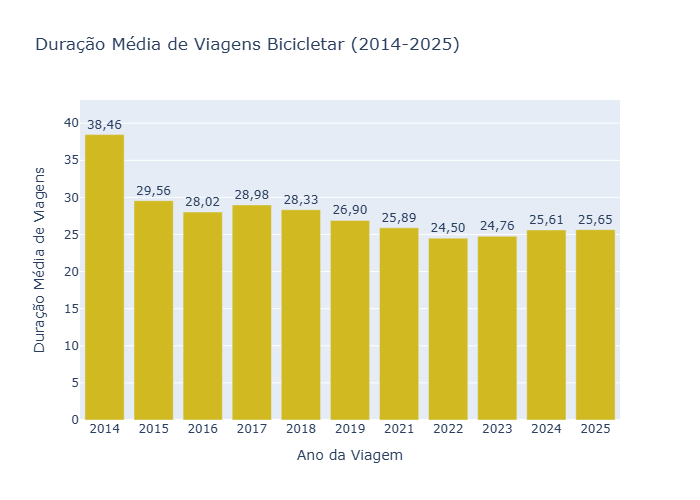

In [ ]:
# Plotar o gráfico de barras com a duração média das viagens por ano
media_duracao = dados_total.groupby(['AnoViagem'])['DuracaoViagem'].mean().reset_index(name='Duração média de viagens') # Agrupando antes para evitar alto consumo de memória

grafico2 = px.bar(
    media_duracao,
    x='AnoViagem', 
    y='Duração média de viagens',
    text_auto='.2f', # Exibir os valores das colunas com duas casas decimais
    title='Duração Média de Viagens Bicicletar (2014-2025)',
    labels={'AnoViagem': 'Ano da Viagem', 'Duração média de viagens': 'Duração Média de Viagens'},
    color_discrete_sequence=['#d1ba21']
)

grafico2.update_layout(separators=",.") # Mudar os separadores de milhar e decimal para o padrão brasileiro (milhar: ponto, decimal: vírgula)

grafico2.update_traces(
    textposition='outside', # Coloca o texto acima da coluna
    textangle=0,            # Deixa o texto na horizontal 
    cliponaxis=False        # Evita que o texto da coluna mais alta seja cortado pelo topo do gráfico          
)
grafico2.show(renderer="png") # Exibir o gráfico de forma que seja possível visualizar no GitHub

##### A observação do gráfico permite que seja indentificada certa tendência de viagens mais curtas com o passar dos anos. Visando determinar se essa interpretação é correta, seguiu-se com o Teste de Mann-Kendall. 

In [46]:
mk_duracao = mk.original_test(media_duracao['Duração média de viagens']) # Realizar o teste de Mann-Kendall para verificar a tendência da duração média das viagens ao longo dos anos
if mk_duracao.p < 0.05: # Se a hipotese nula for rejeitada, significa que há uma tendência significativa na duração média das viagens
    print(f"Tendência monotônica detectada na duração média das viagens (p-valor: {mk_duracao.p:.3f})")
    if mk_duracao.trend == 'decreasing':
        print(f"A duração média das viagens está diminuindo {abs(mk_duracao.slope):.3f} a cada ano.") 
    elif mk_duracao.trend == 'increasing':
        print(f"A duração média das viagens está aumentando {mk_duracao.slope:.3f} a cada ano.")
else:
    print("Não foi detectada uma tendência monotônica na duração média das viagens.")

Tendência monotônica detectada na duração média das viagens (p-valor: 0.003)
A duração média das viagens está diminuindo 0.666 a cada ano.
